## Importing Packages

In [1]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.plotting.setup_mpl()

## Loading Session Data

In [2]:
year = 2025
race = 'Azerbaijan Grand Prix'

session = fastf1.get_session(year, race, 'R')
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (3.55 GB) C:\Users\odath\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Azerbaijan Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching tr

## Load and Prepare Lap Data

In [3]:
laps = session.laps

laps = laps[[
    'Driver', 'LapNumber', 'LapTime',
    'Compound', 'TyreLife', 'Stint', 'Team'
]].dropna()

laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps.head()

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,Team,LapTimeSeconds
0,VER,1.0,0 days 00:02:08.681000,HARD,1.0,1.0,Red Bull Racing,128.681
4,VER,5.0,0 days 00:01:47.655000,HARD,5.0,1.0,Red Bull Racing,107.655
5,VER,6.0,0 days 00:01:47.127000,HARD,6.0,1.0,Red Bull Racing,107.127
6,VER,7.0,0 days 00:01:46.484000,HARD,7.0,1.0,Red Bull Racing,106.484
7,VER,8.0,0 days 00:01:46.133000,HARD,8.0,1.0,Red Bull Racing,106.133


## Driver Comparison on Same Compound

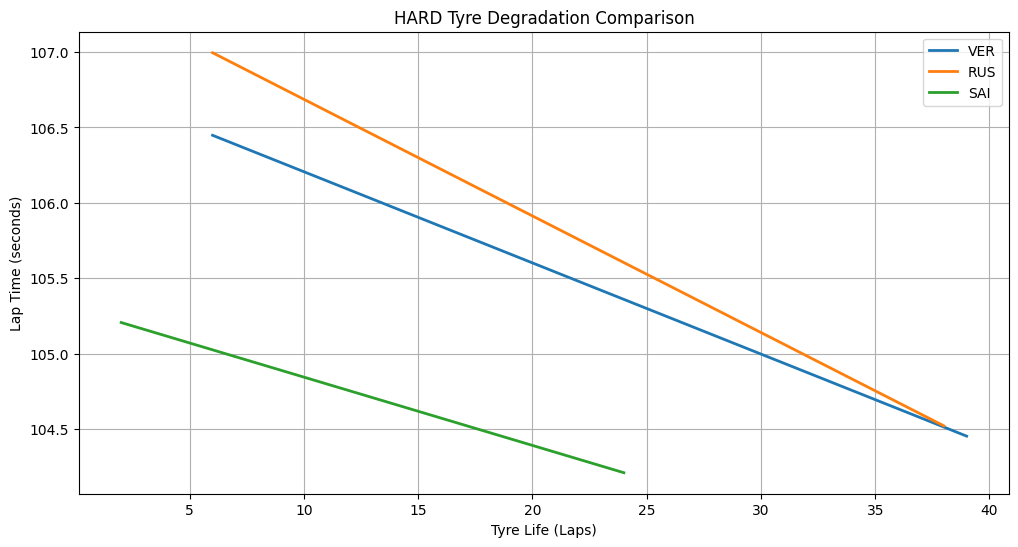

In [4]:
results = session.results

results = results.head(3)
drivers = results['Abbreviation']

# Get compounds used by each driver
driver_compounds = {
    drv: set(laps[laps['Driver'] == drv]['Compound'].unique())
    for drv in drivers
}

# Find intersection (common compounds)
common_compounds = set.intersection(*driver_compounds.values())

# Pick one (e.g., most frequent among common ones)
if common_compounds:
    compound_counts = laps[laps['Compound'].isin(common_compounds)]['Compound'].value_counts()
    compound = compound_counts.idxmax()
else:
    print("⚠️ No common compound found among top 3 drivers")
    compound = None

plt.figure(figsize=(12, 6))

for drv in drivers:
    data = laps[
        (laps['Driver'] == drv) &
        (laps['Compound'] == compound)
    ].copy()

    # 🔧 Step 1: Clean data
    data = data.dropna(subset=['TyreLife', 'LapTimeSeconds'])
    data = data[data['TyreLife'] > 1]
    data = data[data['LapTimeSeconds'] < data['LapTimeSeconds'].quantile(0.95)]

    if data.empty:
        print(f"⚠️ Skipping {drv} (no data)")
        continue

    if len(data) < 3:
        continue

    z = np.polyfit(data['TyreLife'], data['LapTimeSeconds'], 1)
    p = np.poly1d(z)

    plt.plot(
        data['TyreLife'],
        p(data['TyreLife']),
        label=drv,
        linewidth=2
    )

plt.title(f"{compound} Tyre Degradation Comparison")
plt.xlabel("Tyre Life (Laps)")
plt.ylabel("Lap Time (seconds)")
plt.legend()
plt.grid(True)

plt.show()

## Driver Comparison on Different Compound

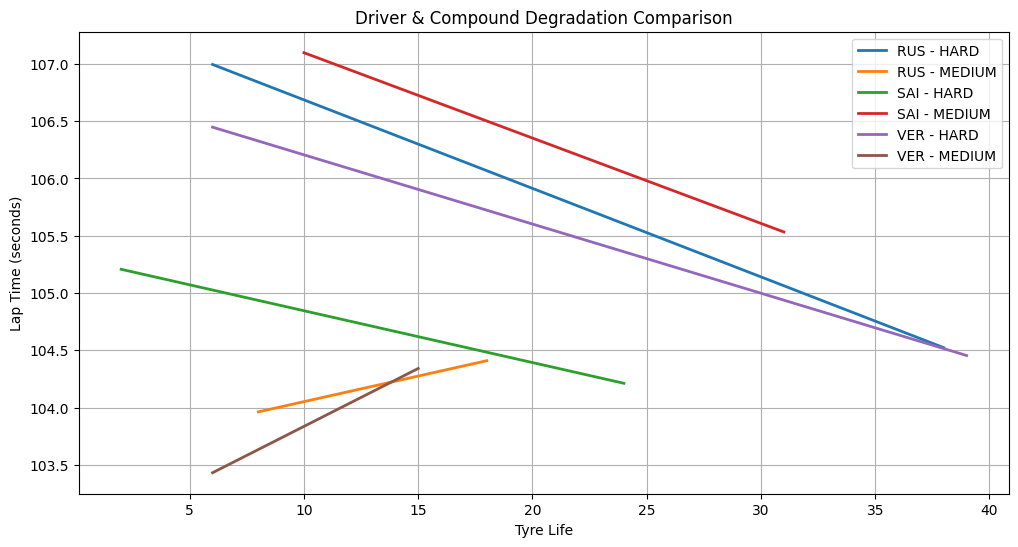

In [5]:
comparison = laps[laps['Driver'].isin(drivers)].copy()

plt.figure(figsize=(12, 6))

plotted = False

for (drv, comp), data in comparison.groupby(['Driver', 'Compound']):

    # 🔧 Step 1: Clean data
    data = data.dropna(subset=['TyreLife', 'LapTimeSeconds'])
    data = data[data['TyreLife'] > 1]
    data = data[data['LapTimeSeconds'] < data['LapTimeSeconds'].quantile(0.95)]

    if data.empty:
        continue

    data = data.sort_values('TyreLife')

    if len(data) < 3:
        continue

    # 🔧 Step 3: Use linear smoothing (IMPORTANT)
    z = np.polyfit(data['TyreLife'], data['LapTimeSeconds'], 1)
    p = np.poly1d(z)

    plt.plot(
        data['TyreLife'],
        p(data['TyreLife']),
        label=f"{drv} - {comp}",
        linewidth=2
    )

    plotted = True

# ✅ Avoid legend warning
if plotted:
    plt.legend()

plt.xlabel("Tyre Life")
plt.ylabel("Lap Time (seconds)")
plt.title("Driver & Compound Degradation Comparison")
plt.grid(True)

plt.show()